In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# 1. Data Collection (Pulling directly from a public repository for speed)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
import pandas as pd
from google.colab import sheets

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1cfkup-Qtm7eJA3swNyuPCtTFveXdgLXNwHx8hw9LRB0/edit#gid=0


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


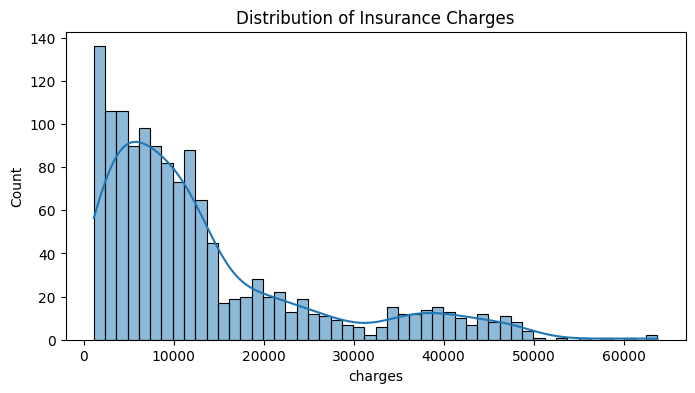

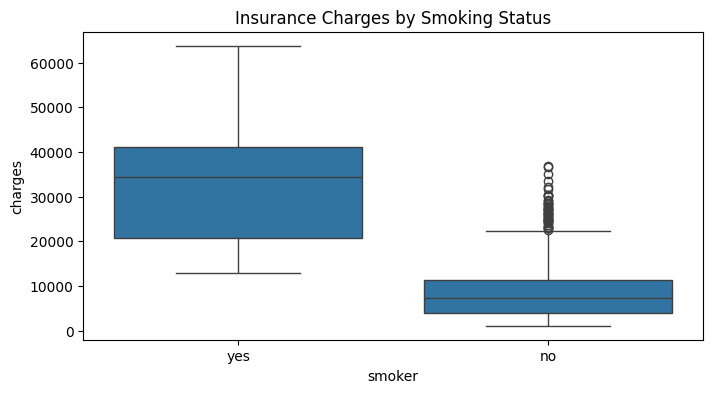

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection (Pulling directly from a public repository for speed)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# 2. EDA & Data Cleaning
# Check for missing values (Cleaning step)
print(df.isnull().sum())

# Visualize the Cost Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

# Visualize Cost vs. Smoking (Smoking is a massive driver of cost)
plt.figure(figsize=(8, 4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 3. Feature Selection & Encoding
# Convert categorical variables (sex, smoker, region) into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 4. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (1070, 8)
Testing data: (268, 8)


In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 5. Baseline Linear Regression
# Under the hood, this minimizes the Cost Function using a closed-form solution (or Gradient Descent for massive datasets)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions on new (test) data
y_pred_lr = lr_model.predict(X_test)

# Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Baseline Linear Regression ---")
print(f"RMSE: ${rmse_lr:,.2f}")
print(f"R2 Score: {r2_lr:.4f}")
# An R2 of ~0.78 means we explain 78% of the variance in medical costs.

--- Baseline Linear Regression ---
RMSE: $5,796.28
R2 Score: 0.7836


In [14]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline # Added this import

# 6. Polynomial Regression with Regularization (Ridge)
# We add polynomial features to capture non-linear relationships (e.g., BMI * Smoker).
# Because polynomial features can cause overfitting, we use Ridge (L2 Regularization) to penalize large weights.

# Create a pipeline that scales data, creates polynomial features, and fits a Ridge model
poly_ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0)) # Alpha controls the Regularization strength
])

poly_ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = poly_ridge_pipeline.predict(X_test)

# Evaluation
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("--- Polynomial Ridge Regression ---")
print(f"RMSE: ${rmse_ridge:,.2f}")
print(f"R2 Score: {r2_ridge:.4f}")

--- Polynomial Ridge Regression ---
RMSE: $4,551.00
R2 Score: 0.8666


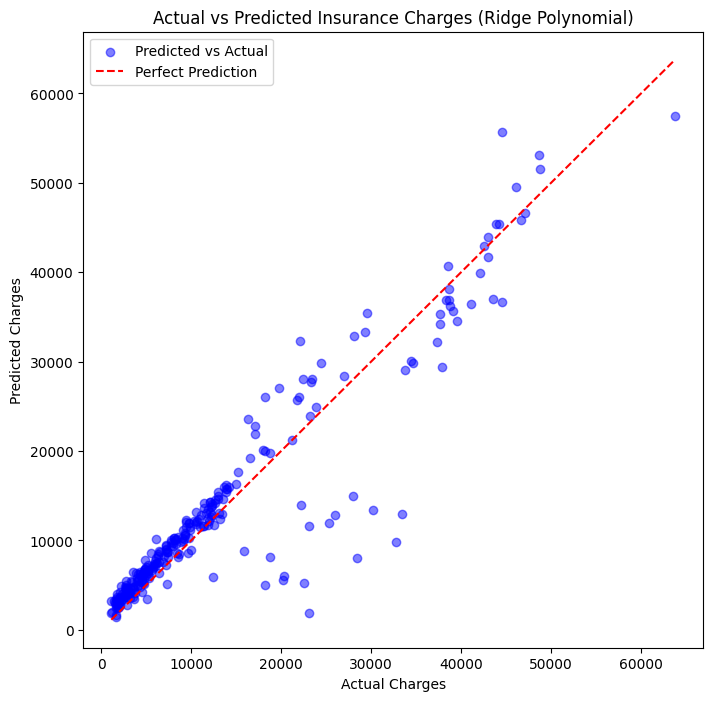

In [15]:
# 7. Visual Model Evaluation
# A good model will have predictions falling tightly along the red diagonal line.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges (Ridge Polynomial)')
plt.legend()
plt.show()

In [17]:
# 8. Saving the trained model
# We save the entire pipeline so that new data is automatically scaled and polynomial-transformed.
import os
import joblib # Added this line
os.makedirs('../models', exist_ok=True)
model_path = '../models/final_ridge_model.pkl'

joblib.dump(poly_ridge_pipeline, model_path)
print(f"Model successfully saved to {model_path}")

# To load and predict later:
# loaded_model = joblib.load(model_path)
# loaded_model.predict(new_patient_data)

Model successfully saved to ../models/final_ridge_model.pkl


In [18]:
import joblib
import pandas as pd

# 1. Load the model we saved earlier in the notebook
# In Colab, it was saved to this path by default
model_path = '../models/final_ridge_model.pkl'
model_pipeline = joblib.load(model_path)

# 2. Define a hardcoded patient profile
# Profile: 30-year-old male, BMI 28.5, 2 children, non-smoker, from the northwest
patient_data = {
    'age': [30],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [1],           # 1 for male, 0 for female
    'smoker_yes': [0],         # 1 for smoker, 0 for non-smoker
    'region_northwest': [1],   # 1 for northwest, 0 otherwise
    'region_southeast': [0],
    'region_southwest': [0]
}

# 3. Convert to DataFrame
new_patient_df = pd.DataFrame(patient_data)

# 4. Make the prediction
predicted_cost = model_pipeline.predict(new_patient_df)[0]

# 5. Output the results
print("-" * 40)
print("PATIENT PROFILE:")
print(f"Age: 30 | BMI: 28.5 | Children: 2")
print(f"Sex: Male | Smoker: No | Region: Northwest")
print("-" * 40)
print(f"PREDICTED INSURANCE CHARGE: ${predicted_cost:,.2f}")
print("-" * 40)

----------------------------------------
PATIENT PROFILE:
Age: 30 | BMI: 28.5 | Children: 2
Sex: Male | Smoker: No | Region: Northwest
----------------------------------------
PREDICTED INSURANCE CHARGE: $6,759.28
----------------------------------------
